# Exercise 6: Operator Splitting Methods

## Learning Objectives

By completing this exercise, you will:
- Understand different operator splitting strategies (Additive, Lie-Trotter, Strang)
- Analyze the accuracy and stability of splitting methods
- Compare splitting approaches with direct integration
- Investigate when operator splitting fails

In [1]:
import torch 
import matplotlib.pyplot as plt
import math
from math import pi
import numpy as np
import importlib
import nm_lib.nm_ex.nm_lib_ex_6 as nm6
importlib.reload(nm6)


def run_add_lib(x_t, u0_t, nt, a, b, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    t_np, unnt_np = nm6.ops_Lax_LL_Add(
        x_np, u0_np, nt=nt, a=a, b=b, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    u_end = torch.tensor(unnt_np[-1], dtype=u0_t.dtype, device=u0_t.device)
    return t_np, unnt_np, u_end


def run_lie_lib(x_t, u0_t, nt, a, b, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    t_np, unnt_np = nm6.ops_Lax_LL_Lie(
        x_np, u0_np, nt=nt, a=a, b=b, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    u_end = torch.tensor(unnt_np[-1], dtype=u0_t.dtype, device=u0_t.device)
    return t_np, unnt_np, u_end


def run_strang_lib(x_t, u0_t, nt, a, b, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    t_np, unnt_np = nm6.ops_Lax_LL_Strange(
        x_np, u0_np, nt=nt, a=a, b=b, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    u_end = torch.tensor(unnt_np[-1], dtype=u0_t.dtype, device=u0_t.device)
    return t_np, unnt_np, u_end


def run_mixed_hyman_lib(x_t, u0_t, nt, a, b, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u0_np = u0_t.detach().cpu().numpy()

    t_np, unnt_np = nm6.osp_Lax_LH_Strange(
        x_np, u0_np, nt=nt, a=a, b=b, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    u_end = torch.tensor(unnt_np[-1], dtype=u0_t.dtype, device=u0_t.device)
    return t_np, unnt_np, u_end

---

## Introduction

Operator splitting allows solving complex PDEs by breaking them into simpler sub-problems. See the [wiki: Operator Splitting](https://github.com/AST-Course/AST5110/wiki/Operator-splitting) for background.

---

## Part 1: Operator Splitting Precision

### The Problem

Solve the advection equation with two velocity components:

$$\frac{\partial u}{\partial t} = -a \frac{\partial u}{\partial x} - b \frac{\partial u}{\partial x} \tag{1}$$

Following the setup from [Exercise 2b](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_2b.ipynb).

**Setup:**
- Domain: $x \in [-2.6, 2.6]$
- Parameters: $a = -0.7$, $b = -0.3$
- Periodic boundary conditions
- Initial condition:
$$u(x,t=t_0) = \cos^2\left(\frac{6\pi x}{5}\right) / \cosh(5x^2) \tag{2}$$
- Resolution: `nump = 256`, 100 time steps

### Task 1.1: Implement Four Approaches

Solve the evolution using:

| Method | Description | Implementation |
|--------|-------------|----------------|
| **1. Additive OS** | $u^{n+1} = u^n + \Delta t(A + B)u^n$ | `osp_LL_Add` |
| **2. Lie-Trotter OS** | $u^{n+1} = e^{B\Delta t}e^{A\Delta t}u^n$ | `osp_LL_Lie` |
| **3. Strang OS** | $u^{n+1} = e^{A\frac{\Delta t}{2}}e^{B\Delta t}e^{A\frac{\Delta t}{2}}u^n$ | `osp_LL_Strang` |
| **4. No splitting** | $\frac{\partial u}{\partial t} = -(a+b)\frac{\partial u}{\partial x}$ | Direct |

> **Suggestion:** Use the Lax method with `deriv_cent` for all cases. Ensure boundaries are properly handled.

Using device: cuda
dx = 0.0203125 dt = 0.01625 CFL = 0.8


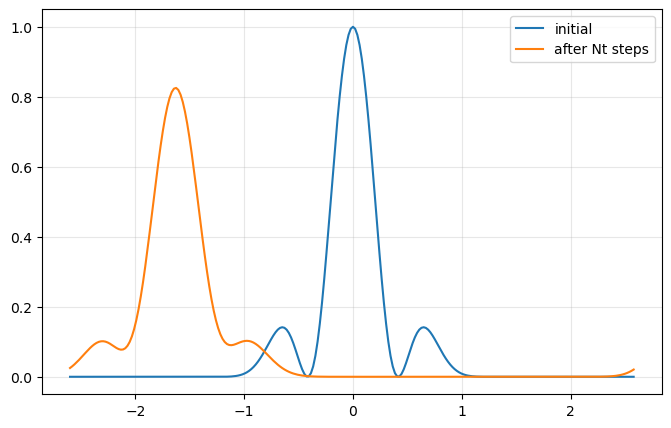

dx = 0.0203125 dt = 0.01625 CFL(max) = 0.8


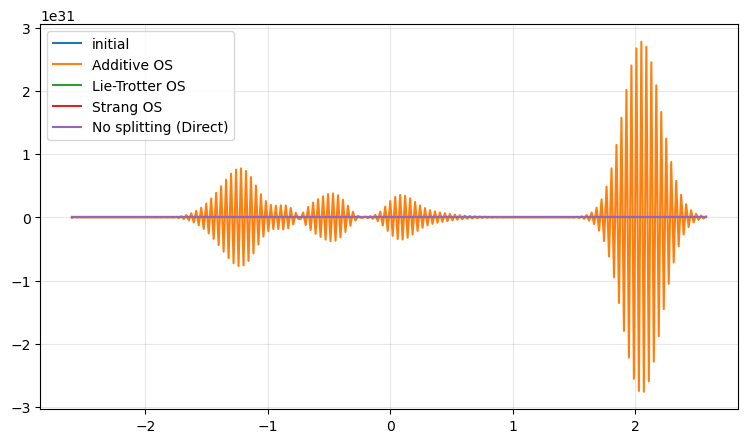

In [2]:
# The exercise 6 OPerator Splitting Methods.
# In this exececise we are going to work with the splitting methods.
# Try to use Torch if possible 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

print("Using device:", device)
#Part 1 Pperator splitting Precision
# Parameters
x0= -2.6
xf = 2.6
a, b = -0.7, -0.3
Nx = 256
Nt = 100

#Periodic gird. Remember don't include endpoint.

L = xf-x0
dx = L / Nx
x = x0+dx* torch.arange(Nx, device=device, dtype=dtype)


# Solve the advection equation.

#First we define the intial value condition.
def Advection_intial(x):
 
    return torch.cos((6*pi*x)/5)**2 / torch.cosh(5*x**2)


# Define the step loop


def step_loop(u, c, dx, dt):
    N = u.numel()
    u_new = torch.empty_like(u)

    lam = c * dt / (2.0 * dx)

    for j in range(N):
        
        jp = (j + 1) % N   # j+1
        jm = (j - 1) % N   # j-1

        u_new[j] = 0.5 * (u[jp] + u[jm]) - lam * (u[jp] - u[jm])

    return u_new



#We consider the equation  u_t = -au:x -bu_x
#This is same as u_t = -(a+b)u_x

#And the speed is c = a+b

u = Advection_intial(x).clone()

c = a+b 
cfl = 0.8
dt = cfl * dx / abs(c) 
print("dx =", dx, "dt =", dt, "CFL =", abs(c)*dt/dx)


for n in range(Nt):
    u = step_loop(u, c, dx, dt)


plt.figure(figsize=(8,5))
plt.plot(x.cpu().numpy(), Advection_intial(x).cpu().numpy(), label="initial")
plt.plot(x.cpu().numpy(), u.detach().cpu().numpy(), label="after Nt steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

    

# Task 1.1

#First is the Additive OS
# In this method we can caculate every sub problems and take an addition between them,
# And take subtraction between intial value.


# Let F_1(u) = -au_x. F_2(u)= -bu_x
# We take the same intial value, 
#From u^n, we get u_a^ n+1 and  u_b^ n+1
#And get the same u^n+1 =  u_a^ n+1 + u_b^ n+1 -u^n

def step_additive_os(u, a, b, dx, dt):
    ua = step_loop(u, a, dx, dt)   
    ub = step_loop(u, b, dx, dt)   
    return ua + ub - u

#Lie-Trotter OS
#u^{n+1} = e^{B dt} e^{A dt} u^n
def step_lie_ab(u, a, b, dx, dt):
    u1 = step_loop(u, a, dx, dt)
    u2 = step_loop(u1, b, dx, dt)
    return u2
# Strang OS
# Strang: u^{n+1} = e^{A dt/2} e^{B dt} e^{A dt/2} u^n
def step_strang(u, a, b, dx, dt):
    u1 = step_loop(u,  a, dx, dt/2.0)
    u2 = step_loop(u1, b, dx, dt)
    u3 = step_loop(u2, a, dx, dt/2.0)
    return u3
# No spitting
def step_no_splitting(u, a, b, dx, dt):
    c = a + b
    return step_loop(u, c, dx, dt)


cfl_cut = 0.8

cmax = max(abs(a), abs(b), abs(a + b))
dt = cfl_cut * dx / cmax
print("dx =", dx, "dt =", dt, "CFL(max) =", cmax*dt/dx)

U0 = Advection_intial(x)

# use the lib for the splitting methods
_, _, u_add = run_add_lib(x, U0, Nt, a, b, cfl_cut=cfl_cut)
_, _, u_lie = run_lie_lib(x, U0, Nt, a, b, cfl_cut=cfl_cut)
_, _, u_str = run_strang_lib(x, U0, Nt, a, b, cfl_cut=cfl_cut)

def lax_communication_loop(u, eps=0.08):
    N = u.numel()
    u_new = torch.empty_like(u)

    for j in range(N):
        jp = (j + 1) % N
        jm = (j - 1) % N
        u_new[j] = (1.0 - eps) * u[j] + 0.5 * eps * (u[jp] + u[jm])

    return u_new


def step_additive_os_comm(u, a, b, dx, dt, eps=0.08):
    ua = step_loop(u, a, dx, dt)
    ub = step_loop(u, b, dx, dt)
    u_add = ua + ub - u
    u_add = lax_communication_loop(u_add, eps=eps)
    return u_add

# keep direct no-splitting as local baseline
u_dir = U0.clone()
for _ in range(Nt):
    u_dir = step_no_splitting(u_dir, a, b, dx, dt)

# Plot
plt.figure(figsize=(9,5))
plt.plot(x.cpu().numpy(), U0.cpu().numpy(), label="initial")
plt.plot(x.cpu().numpy(), u_add.cpu().numpy(), label="Additive OS")
plt.plot(x.cpu().numpy(), u_lie.cpu().numpy(), label="Lie-Trotter OS")
plt.plot(x.cpu().numpy(), u_str.cpu().numpy(), label="Strang OS")
plt.plot(x.cpu().numpy(), u_dir.cpu().numpy(), label="No splitting (Direct)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Task 1.2: Stability Analysis

Start with `cfl_cut = 0.4` and increase up to `0.9`.

**Questions:**
1. Which OS schemes are stable?
2. Which one is more diffusive? Why?

Stability table (simple)

CFL_cut = 0.4
  NoSplit    dt=8.1250e-03   STABLE   max|u|=6.798e-01
  Additive   dt=8.1250e-03   UNSTABLE   max|u|=3.830e+01
  Add+Comm   dt=8.1250e-03   UNSTABLE   max|u|=1.551e+01
  Lie        dt=8.1250e-03   STABLE   max|u|=5.227e-01
  Strang     dt=8.1250e-03   STABLE   max|u|=4.478e-01

CFL_cut = 0.5
  NoSplit    dt=1.0156e-02   STABLE   max|u|=7.015e-01
  Additive   dt=1.0156e-02   UNSTABLE   max|u|=3.854e+01
  Add+Comm   dt=1.0156e-02   UNSTABLE   max|u|=1.563e+01
  Lie        dt=1.0156e-02   STABLE   max|u|=5.278e-01
  Strang     dt=1.0156e-02   STABLE   max|u|=4.495e-01

CFL_cut = 0.6
  NoSplit    dt=1.2188e-02   STABLE   max|u|=7.310e-01
  Additive   dt=1.2188e-02   UNSTABLE   max|u|=3.883e+01
  Add+Comm   dt=1.2188e-02   UNSTABLE   max|u|=1.583e+01
  Lie        dt=1.2188e-02   STABLE   max|u|=5.342e-01
  Strang     dt=1.2188e-02   STABLE   max|u|=4.516e-01

CFL_cut = 0.7
  NoSplit    dt=1.4219e-02   STABLE   max|u|=7.710e-01
  Additive   dt=1.4219e

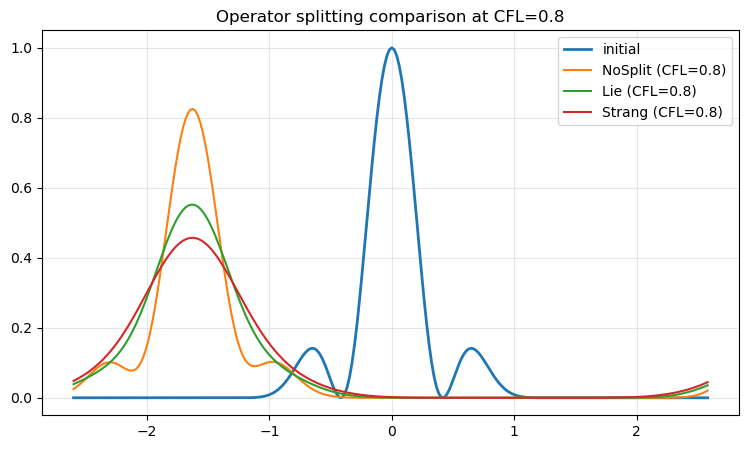

In [3]:

# Task 1.2: Stability Analysis 


def run_scheme(stepper, name, cfl_cut):
    cmax = max(abs(a), abs(b), abs(a + b))
    dt = cfl_cut * dx / cmax

    u = Advection_intial(x).clone()

    l2_list = []
    umax_list = []

    stable = True
    for n in range(Nt):
        u = stepper(u, a, b, dx, dt)

         # record norms to judge stability
        if u is None:
            print("BUG: stepper returned None ->", name, "at step", n)
            stable = False
            break

        l2 = torch.norm(u).item()
        umax = torch.max(torch.abs(u)).item()

        l2_list.append(l2)
        umax_list.append(umax)

         # very simple "blow-up" rule
        if (not torch.isfinite(u).all().item()) or (umax > 50) or (l2 > 50):
            stable = False
            break

    return stable, dt, u, l2_list, umax_list

# Apply the results.
def stepper_nosplit(u, a, b, dx, dt): 
    return step_no_splitting(u, a, b, dx, dt)
def stepper_add(u, a, b, dx, dt):     
    return step_additive_os(u, a, b, dx, dt)
def stepper_lie(u, a, b, dx, dt):     
    return step_lie_ab(u, a, b, dx, dt)
def stepper_strang(u, a, b, dx, dt): 
    return step_strang(u, a, b, dx, dt)
def stepper_add_comm(u, a, b, dx, dt):
    return step_additive_os_comm(u, a, b, dx, dt, eps=0.08)
schemes = [
    ("NoSplit", stepper_nosplit),
    ("Additive", stepper_add),
    ("Add+Comm", stepper_add_comm),
    ("Lie", stepper_lie),
    ("Strang", stepper_strang),
]

cfl_list = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("Stability table (simple)")
for cfl_cut in cfl_list:
    print(f"\nCFL_cut = {cfl_cut}")
    for name, stepper in schemes:
        stable, dt, u_end, l2_list, umax_list = run_scheme(stepper, name, cfl_cut)
        tag = "STABLE" if stable else "UNSTABLE"
        print(f"  {name:9s}  dt={dt:.4e}   {tag}   max|u|={umax_list[-1]:.3e}")

# pick one CFL to visualize
cfl_show = 0.8  
plt.figure(figsize=(9,5))
plt.plot(x.cpu().numpy(), Advection_intial(x).cpu().numpy(), label="initial", linewidth=2)

for name, stepper in schemes:
    stable, dt, u_end, l2_list, umax_list = run_scheme(stepper, name, cfl_show)
    if stable:
        plt.plot(x.cpu().numpy(), u_end.detach().cpu().numpy(), label=f"{name} (CFL={cfl_show})")
    else:
        print(f"{name} is unstable at CFL={cfl_show}, skip plot.")

plt.title(f"Operator splitting comparison at CFL={cfl_show}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## Part 2: When Does Operator Splitting Fail?

### Task 2.1: Mixed Methods with Strang Splitting

Use Strang splitting from Part 1 but apply a **predictor-corrector** explicit method for one operator.

**Setup:**
- Resolution: `nump = 512`, 500 steps, `cfl_cut = 0.8`

The Hyman predictor-corrector method is already implemented in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_6.py) (used in Bifrost).

**Implementation:** Fill in `osp_Lax_LH_Strang`.

**Question:** What do you notice?

### Task 2.2: Verify Splitting Consistency (Optional)

Apply the Hyman predictor-corrector method to the full Burgers equation and verify:

$$u^{n+1} = F\, u^n \Delta t \approx G\, u^n \Delta t + H\, u^n \Delta t$$

---

## Hints

<details>
<summary><b>Hint 1: Order of accuracy</b></summary>

- **Additive:** First-order accurate
- **Lie-Trotter:** First-order accurate
- **Strang:** Second-order accurate (symmetric splitting)
</details>

<details>
<summary><b>Hint 2: Why splitting can fail</b></summary>

When operators don't commute ($[A,B] \neq 0$), splitting introduces errors. Mixing methods with different numerical properties (e.g., Lax + predictor-corrector) can cause additional instabilities.
</details>

<details>
<summary><b>Hint 3: Strang splitting structure</b></summary>

```python
# Half step with operator A
u_half = step_A(u, dt/2)
# Full step with operator B  
u_full = step_B(u_half, dt)
# Half step with operator A
u_new = step_A(u_full, dt/2)
```
</details>

Nx = 512 Nt = 500 dx = 0.01015625 dt = 0.008125 CFL = 0.8


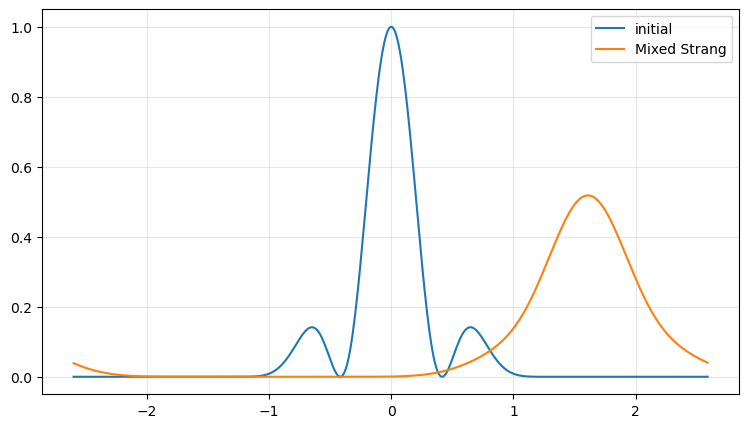

In [4]:
# Part 2 
# Mixed methods with Strang splitting:
"""
# central derivative 
def deriv_cent(u, dx):
    N = u.numel()
    dudx = torch.empty_like(u)
    for j in range(N):
        jp = (j + 1) % N
        jm = (j - 1) % N
        dudx[j] = (u[jp] - u[jm]) / (2.0 * dx)
    return dudx

# predictor-corrector time step for linear advection: u_t = -c u_x

def step_PC(u, c, dx, dt):
    # predictor
    k1 = -c * deriv_cent(u, dx)
    u_pred = u + dt * k1

    # corrector
    k2 = -c * deriv_cent(u_pred, dx)
    u_new = u + 0.5 * dt * (k1 + k2)
    return u_new

# Strang with mixed methods: Lax for A, PC for B

# Strang: apply A half step, then B full step, then A half step
def osp_Lax_LH_Strang(u, a, b, dx, dt):
    u1 = step_loop(u, a, dx, dt/2.0)   # A half step 
    u2 = step_PC(u1,  b, dx, dt)       # B full step 
    u3 = step_loop(u2, a, dx, dt/2.0)  # A half step 
    return u3

# run 
# nump=512, 500 steps, cfl_cut=0.8
Nx2 = 512
Nt2 = 500
# periodic grid 
dx2 = (xf - x0) / Nx2
x2  = x0 + dx2 * torch.arange(Nx2, device=device, dtype=dtype)
# initial condition
u_init2 = Advection_intial(x2).clone()
# choose dt from CFL based on the max wave speed among
cfl_cut = 0.8
cmax = max(abs(a), abs(b), abs(a + b))
dt2 = cfl_cut * dx2 / cmax
print("Nx =", Nx2, "Nt =", Nt2, "dx =", dx2, "dt =", dt2, "CFL =", cmax*dt2/dx2)

# time stepping
u_mix = u_init2.clone()
for _ in range(Nt2):
    u_mix = osp_Lax_LH_Strang(u_mix, a, b, dx2, dt2)
"""
"""
#For the PC step I used the standard second-order Heun’s method (explicit trapezoidal predictor–corrector): an Euler predictor followed by a trapezoidal corrector.
#References
#https://leifh.folk.ntnu.no/teaching/tkt4140/._main015.html
"""

# Part 2
# Mixed methods with Strang splitting:
# A-step with Lax, B-step with Hyman from nm_lib

Nx2 = 512
Nt2 = 500

dx2 = (xf - x0) / Nx2
x2  = x0 + dx2 * torch.arange(Nx2, device=device, dtype=dtype)

u_init2 = Advection_intial(x2).clone()

cfl_cut = 0.8
cmax = max(abs(a), abs(b), abs(a + b))
dt2 = cfl_cut * dx2 / cmax
print("Nx =", Nx2, "Nt =", Nt2, "dx =", dx2, "dt =", dt2, "CFL =", cmax*dt2/dx2)

# run mixed Strang with Hyman from the lib
t_mix_np, unnt_mix_np, u_mix = run_mixed_hyman_lib(
    x2, u_init2, Nt2, a, b, cfl_cut=cfl_cut
)


#Plot
plt.figure(figsize=(9,5))
plt.plot(x2.cpu().numpy(), u_init2.cpu().numpy(), label="initial")
plt.plot(x2.cpu().numpy(), u_mix.detach().cpu().numpy(), label="Mixed Strang")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show() 

In [5]:
# Conclusion
# We consider the CFL in [0.4, 0.9].
# The Strang, Lie-Trotter, and also the no-splitting direct method look stable in this range.
# The additive operator splitting is unstable and grows oscillations very fast.
#The communication step helps, but the additive splitting is still unstable in the present test.

# When replacing the predictor-corrector subsolver by the Hyman method from nm_lib,
# an important issue appears. The Hyman method is not a pure one-step evolution operator,
# because it requires additional history variables such as fold and dtold.
# Therefore, the B-subsolver is no longer of the form u^{n+1} = S_B(dt)u^n only.
# This breaks the standard requirement behind operator splitting, where each split operator
# should define a closed time evolution map depending only on the current state and the time step.

# In contrast, the Heun predictor-corrector method used before is a genuine one-step method,
# so it can be inserted into operator splitting without this extra memory issue.

#The error is that the Hyman method is not a true one-step split operator, since it needs extra history variables